# Практика к занятию 5: Логистическая регрессия и SVM
В этой практике мы разберём два классических алгоритма классификации:
- **Логистическая регрессия** (Logistic Regression)
- **Метод опорных векторов (SVM)**

Мы сравним ручные реализации с готовыми из `scikit-learn`, посмотрим на разделяющие границы и обсудим разницу между hard/soft margin и kernel trick.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_circles, load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import pandas as pd
%matplotlib inline

## Шаг 1. Подготовка данных (Iris)

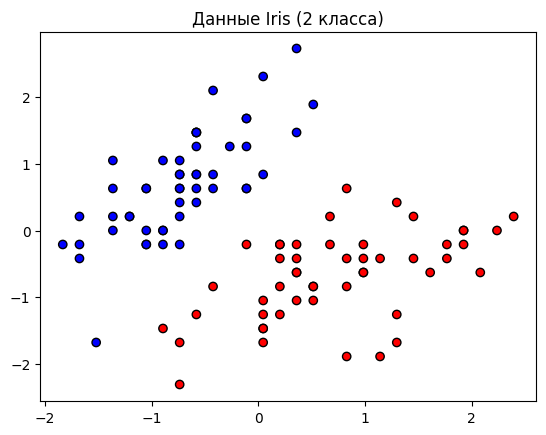

In [ ]:
# Возьмём только 2 класса (setosa vs versicolor) и 2 признака для удобной визуализации
iris = load_iris()
X = iris.data[:100, :2]  # только 2 признака
y = iris.target[:100]    # только классы 0 и 1

# Масштабируем
scaler = StandardScaler()
X = scaler.fit_transform(X)

plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolor='k')
plt.title('Данные Iris (2 класса)')
plt.show()

## Шаг 2. Ручная реализация логистической регрессии

In [ ]:
class ManualLogistic:
    def __init__(self, lr=0.1, n_iter=1000):
        self.lr = lr
        self.n_iter = n_iter

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        self.b = 0
        for _ in range(self.n_iter):
            z = np.dot(X, self.w) + self.b
            h = self.sigmoid(z)
            grad_w = np.dot(X.T, (h - y)) / y.size
            grad_b = np.mean(h - y)
            self.w -= self.lr * grad_w
            self.b -= self.lr * grad_b

    def predict(self, X):
        return (self.sigmoid(np.dot(X, self.w) + self.b) >= 0.5).astype(int)

manual_log = ManualLogistic(lr=0.01, n_iter=100)
manual_log.fit(X, y)
y_pred_manual = manual_log.predict(X)
print('Точность (ручная лог. регрессия):', accuracy_score(y, y_pred_manual))

Точность (ручная лог. регрессия): 0.99


## Шаг 3. LogisticRegression из sklearn

In [ ]:
logreg = LogisticRegression()
logreg.fit(X, y)
y_pred_sklearn = logreg.predict(X)
print('Точность (sklearn лог. регрессия):', accuracy_score(y, y_pred_sklearn))

Точность (sklearn лог. регрессия): 1.0


### Визуализация разделяющей границы

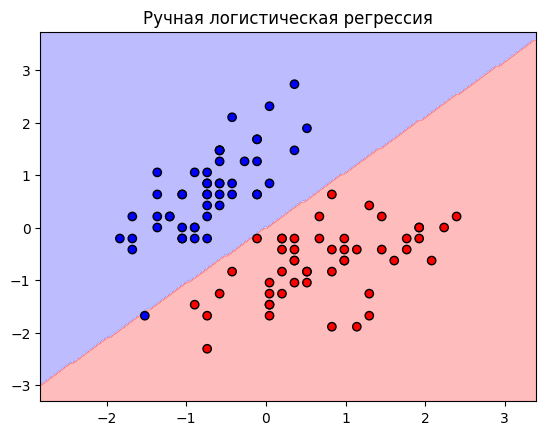

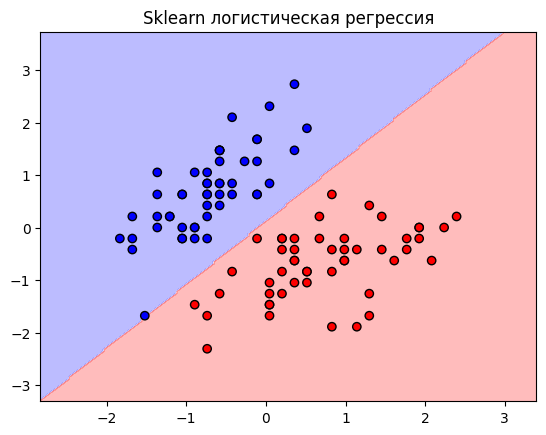

In [ ]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolor='k')
    plt.title(title)
    plt.show()

plot_decision_boundary(manual_log, X, y, 'Ручная логистическая регрессия')
plot_decision_boundary(logreg, X, y, 'Sklearn логистическая регрессия')

## Шаг 4. Ручная реализация SVM (hard margin через hinge loss)

Точность (ручной SVM): 0.98


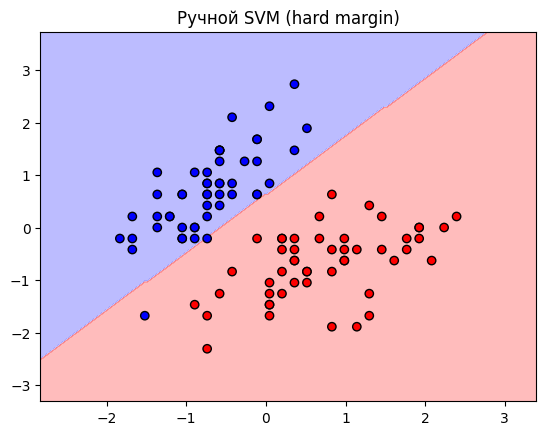

In [ ]:
class ManualSVM:
    def __init__(self, lr=0.001, n_iter=1000, C=1000):
        self.lr = lr
        self.n_iter = n_iter
        self.C = C

    def fit(self, X, y):
        y_ = np.where(y == 0, -1, 1)  # классы -1 и 1
        self.w = np.zeros(X.shape[1])
        self.b = 0
        for _ in range(self.n_iter):
            for idx, x_i in enumerate(X):
                condition = y_[idx] * (np.dot(x_i, self.w) - self.b) >= 1
                if condition:
                    self.w -= self.lr * (2 * self.w)
                else:
                    self.w -= self.lr * (2 * self.w - self.C * y_[idx] * x_i)
                    self.b -= self.lr * self.C * y_[idx]

    def predict(self, X):
        return np.where(np.dot(X, self.w) - self.b >= 0, 1, 0)

manual_svm = ManualSVM()
manual_svm.fit(X, y)
y_pred_svm_manual = manual_svm.predict(X)
print('Точность (ручной SVM):', accuracy_score(y, y_pred_svm_manual))
plot_decision_boundary(manual_svm, X, y, 'Ручной SVM (hard margin)')

## Шаг 5. SVM из sklearn

Точность (sklearn SVM linear): 0.99


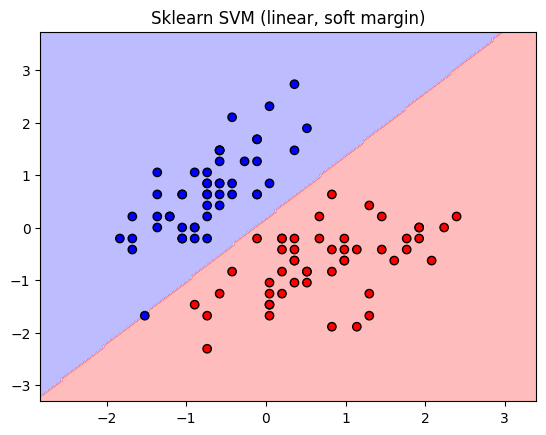

In [ ]:
svm_clf = SVC(kernel='linear', C=1.0)
svm_clf.fit(X, y)
y_pred_sklearn_svm = svm_clf.predict(X)
print('Точность (sklearn SVM linear):', accuracy_score(y, y_pred_sklearn_svm))
plot_decision_boundary(svm_clf, X, y, 'Sklearn SVM (linear, soft margin)')

## Шаг 6. Kernel trick: Poly, RBF, Sigmoid

In [ ]:
help(SVC)

Help on class SVC in module sklearn.svm._classes:

class SVC(sklearn.svm._base.BaseSVC)
 |  SVC(*, C=1.0, kernel='rbf', degree=3, gamma='scale', coef0=0.0, shrinking=True, probability=False, tol=0.001, cache_size=200, class_weight=None, verbose=False, max_iter=-1, decision_function_shape='ovr', break_ties=False, random_state=None)
 |
 |  C-Support Vector Classification.
 |
 |  The implementation is based on libsvm. The fit time scales at least
 |  quadratically with the number of samples and may be impractical
 |  beyond tens of thousands of samples. For large datasets
 |  consider using :class:`~sklearn.svm.LinearSVC` or
 |  :class:`~sklearn.linear_model.SGDClassifier` instead, possibly after a
 |  :class:`~sklearn.kernel_approximation.Nystroem` transformer or
 |  other :ref:`kernel_approximation`.
 |
 |  The multiclass support is handled according to a one-vs-one scheme.
 |
 |  For details on the precise mathematical formulation of the provided
 |  kernel functions and how `gamma`, `

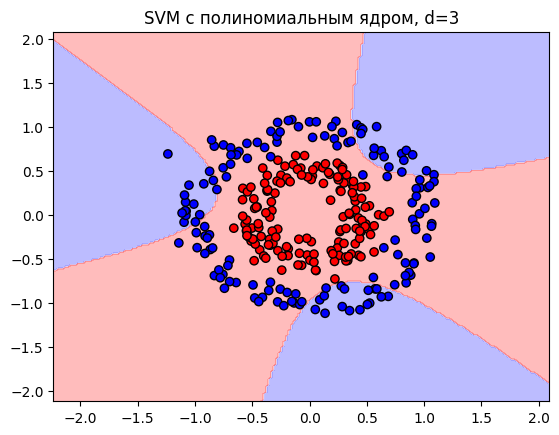

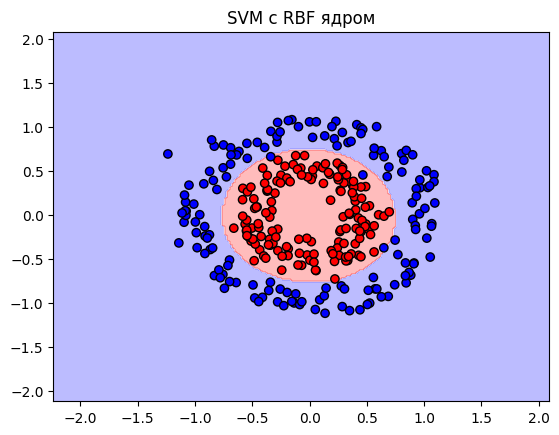

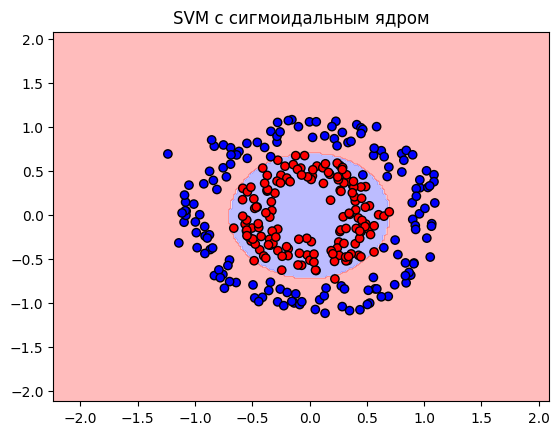

In [ ]:
# Сгенерируем данные, которые линейно неразделимы
X_circ, y_circ = make_circles(n_samples=300, factor=0.5, noise=0.1)

svm_poly = SVC(kernel='poly', degree=3, C=1.0)
svm_poly.fit(X_circ, y_circ)
plot_decision_boundary(svm_poly, X_circ, y_circ, 'SVM с полиномиальным ядром, d=3')

svm_rbf = SVC(kernel='rbf', C=1.0, gamma=0.5)
svm_rbf.fit(X_circ, y_circ)
plot_decision_boundary(svm_rbf, X_circ, y_circ, 'SVM с RBF ядром')

svm_sigmoid = SVC(kernel="sigmoid", coef0=1, C=1)
svm_sigmoid.fit(X_circ, y_circ)
plot_decision_boundary(svm_sigmoid, X_circ, y_circ, 'SVM с сигмоидальным ядром')

## Шаг 7. Kernel trick: кастомные ядра

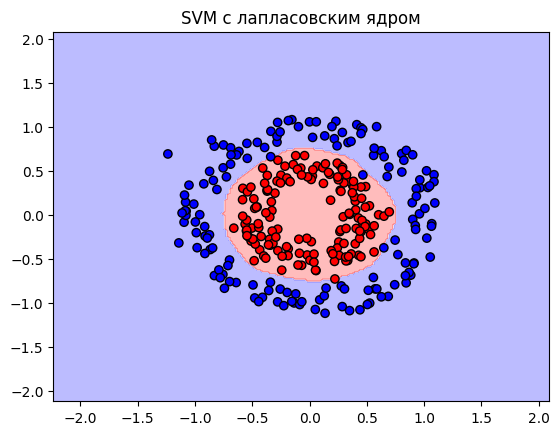

In [ ]:
# Laplacian ядро (как кастомное)
def laplacian_kernel(X, Y):
    # exp(-||x-y|| / sigma)
    sigma = 1.0
    dists = np.sqrt(((X[:, np.newaxis] - Y) ** 2).sum(axis=2))
    return np.exp(-dists / sigma)

clf_laplacian = SVC(kernel=laplacian_kernel, C=1)
clf_laplacian.fit(X_circ, y_circ)
plot_decision_boundary(clf_laplacian, X_circ, y_circ, 'SVM с лапласовским ядром')

In [ ]:
help(cosine_similarity)

Help on function cosine_similarity in module sklearn.metrics.pairwise:

cosine_similarity(X, Y=None, dense_output=True)
    Compute cosine similarity between samples in X and Y.

    Cosine similarity, or the cosine kernel, computes similarity as the
    normalized dot product of X and Y:

    .. code-block:: text

        K(X, Y) = <X, Y> / (||X||*||Y||)

    On L2-normalized data, this function is equivalent to linear_kernel.

    Read more in the :ref:`User Guide <cosine_similarity>`.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples_X, n_features)
        Input data.

    Y : {array-like, sparse matrix} of shape (n_samples_Y, n_features),             default=None
        Input data. If ``None``, the output will be the pairwise
        similarities between all samples in ``X``.

    dense_output : bool, default=True
        Whether to return dense output even when the input is sparse. If
        ``False``, the output is sparse if both input array

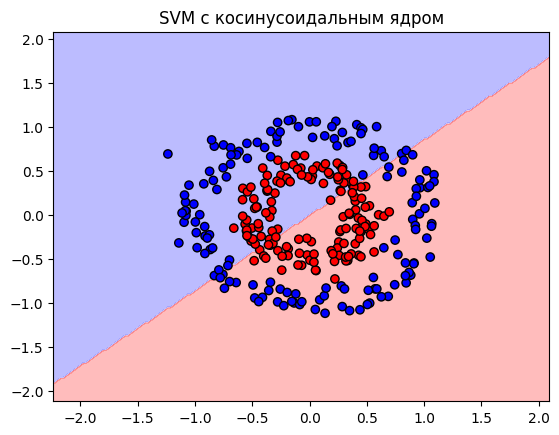

In [ ]:
# Cosine ядро (как кастомное)
clf_cosine = SVC(kernel=cosine_similarity, C=1)
clf_cosine.fit(X_circ, y_circ)
plot_decision_boundary(clf_cosine, X_circ, y_circ, 'SVM с косинусоидальным ядром')